# Movilidad y sostenibilidad ambiental en Londres
### *Trabajo final · Ciudades Inteligentes*

**Autores y NIA:**
- Emilio Hermosa Schiantarelli (100451150)
- Carlos Sanchez Arroyo (100451282)
- Rodrigo Valderrey Tarrero (100451271)

**Curso:** 2025/2026

---

## Índice

1. [Carga de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
   - 2.1 Visión general de la calidad del aire
   - 2.2 Valores nulos e imputación
   - 2.3 Distribuciones y outliers
   - 2.4 Red de transporte TfL
3. [Análisis de contaminación del aire](#3)
   - 3.1 Estacionalidad: patrones horarios y estacionales
   - 3.2 Tendencia interanual
   - 3.3 Comparativa entre estaciones
4. [Análisis de movilidad urbana](#4)
   - 4.1 Grafo de la red TfL (RQ4-B)
   - 4.2 Densidad y cobertura de paradas
5. [Integración movilidad-contaminación](#5)
   - 5.1 Descomposición estacional
   - 5.2 Correlación movilidad-contaminación
6. [Modelos predictivos](#6)
   - 6.1 XGBoost: predicción de NO₂
   - 6.2 Proceso Gaussiano: predicción de serie temporal
7. [Representación geográfica (RQ5)](#7)
8. [Dashboard interactivo (RQ3)](#8)

---

## Pregunta de investigación

> **¿Cuál es la relación entre la infraestructura de transporte público y los niveles de contaminación del aire en Londres?**
>
> En particular, buscamos analizar qué estaciones presentan simultáneamente:
>
> - **mayor riesgo ambiental**, asociado a niveles elevados de contaminación;
> - **menor cobertura de transporte público**, medida a partir de la proximidad y densidad de paradas TfL.


La pregunta que planteamos es si las zonas con peor acceso al transporte público presentan también peores niveles de contaminación del aire. Hemos considerado que es relevante por dos razones principales:

- La contaminación atmosférica afecta a la salud, la calidad de vida y la sostenibilidad de la ciudad. 
- La cobertura del transporte público condiciona la accesibilidad, los patrones de movilidad y, potencialmente, la dependencia del vehículo privado. 

Así pues, estudiar la relación entre ambos factores puede permitir identificar zonas urbanas más vulnerables y entender mejor dónde podrían ser más necesarias medidas de planificación del transporte o incluso de intervención ambiental.

Así pues, consideramos que el presente trabajo cumple los requisitos debido a las siguientes razones:

- Usa una ciudad real y datos abiertos de Londres, cumpliendo RQ1
- Integra movilidad y sostenibilidad ambiental, cumpliendo RQ2
- Permite trabajar con series temporales, redes de transporte y representación geográfica, cumpliendo con RQ4 y RQ5
- Sus resultados pueden resumirse de forma natural en un dashboard interactivo, como pide RQ3

## Carga de librerías

Se importan todas las dependencias. Si algún paquete no está disponible se instala automáticamente.

In [ ]:
import warnings, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
for pkg, pkg_install in [('folium','folium'),('gpytorch','gpytorch'),
                          ('branca','branca'),('geopandas','geopandas'),
                          ('mapclassify','mapclassify'),('h3pandas','h3pandas')]:
    if importlib.util.find_spec(pkg) is None:
        import subprocess; subprocess.run(['pip','install',pkg_install,'-q'], check=False)

import folium
from folium.plugins import MarkerCluster, HeatMap
import branca.colormap as cm_folium
import networkx as nx
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import torch, gpytorch
from gpytorch.models import ExactGP
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel
from gpytorch.distributions import MultivariateNormal
from gpytorch.likelihoods import GaussianLikelihood

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100})
print('Librerías cargadas correctamente.')
import h3pandas
import h3


Librerías cargadas correctamente.


C:\Users\carlo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos <a id='1'></a>

| Dataset | Fuente | Descripción |
|---------|--------|-------------|
| LAQN — NO₂, O₃ | London Air Quality Network API | Mediciones horarias 2019-2023, 5 estaciones |
| TfL stops | TfL Open Data GTFS | 4 084 paradas con coordenadas |
| GTFS pathways | TfL Open Data | 5 100 conexiones entre paradas |

Las estaciones LAQN cubren un gradiente urbano completo: desde vías muy transitadas (MY1 = Marylebone Road, WM6 = Oxford Street) hasta zonas suburbanas (BX1 = Bexley).

In [ ]:
DATA_DIR = 'data_london'
DASH_DIR = 'dashboard'
os.makedirs(f'{DASH_DIR}/img',  exist_ok=True)
os.makedirs(f'{DASH_DIR}/maps', exist_ok=True)

STATION_INFO = {
    'MY1': {'name': 'Westminster – Marylebone Rd',   'type': 'Roadside',         'lat': 51.52254,  'lon': -0.15459},
    'KC1': {'name': 'Kensington – North Kensington', 'type': 'Urban Background', 'lat': 51.52105,  'lon': -0.21349},
    'WM6': {'name': 'Westminster – Oxford Street',   'type': 'Roadside',         'lat': 51.51393,  'lon': -0.15279},
    'CT3': {'name': 'Camden – Bloomsbury',           'type': 'Urban Background', 'lat': 51.52185,  'lon': -0.12740},
    'BX1': {'name': 'Bexley – Belvedere West',       'type': 'Suburban',         'lat': 51.49386,  'lon':  0.10612},
}

def load_laqn_station(station):
    path = f'{DATA_DIR}/raw/laqn/{station}/no2_pm25_o3_2019_2024.csv'
    df = pd.read_csv(path)
    df['ReadingDateTime'] = pd.to_datetime(df['ReadingDateTime'], format='%d/%m/%Y %H:%M')
    wide = {}
    for sp in df['Species'].unique():
        s = df[df['Species'] == sp].set_index('ReadingDateTime')['Value']
        s = s[~s.index.duplicated(keep='first')]
        if s.notna().mean() > 0.01:  # excluir especies con >99% nulos
            wide[sp] = s
    return pd.DataFrame(wide)

dfs_raw = {s: load_laqn_station(s) for s in STATION_INFO}

no2_raw = pd.DataFrame({s: dfs_raw[s]['NO2'] for s in STATION_INFO})
o3_raw  = pd.DataFrame({s: dfs_raw[s]['O3']  for s in STATION_INFO
                         if 'O3' in dfs_raw[s].columns})
no2_raw = no2_raw.sort_index().asfreq('h')
o3_raw  = o3_raw.sort_index().asfreq('h')

stops         = pd.read_csv(f'{DATA_DIR}/metadata/tfl_geo_stops.csv').dropna(subset=['stop_lat','stop_lon'])
gtfs_stops    = pd.read_csv(f'{DATA_DIR}/raw/tfl/tfl_stationdata_gtfs/stops.txt')
gtfs_pathways = pd.read_csv(f'{DATA_DIR}/raw/tfl/tfl_stationdata_gtfs/pathways.txt')
gtfs_stations = gtfs_stops[gtfs_stops['location_type'] == 1].copy()

print(f'NO2  crudo : {no2_raw.shape[0]:,} horas × {no2_raw.shape[1]} estaciones')
print(f'O3   crudo : {o3_raw.shape[0]:,} horas × {o3_raw.shape[1]} estaciones')
print(f'Período    : {no2_raw.index[0].date()} → {no2_raw.index[-1].date()}')
print(f'Paradas TfL: {len(stops):,}')
print(f'Hubs GTFS  : {len(gtfs_stations)}')
print(f'Pathways   : {len(gtfs_pathways):,}')

NO2  crudo : 43,824 horas × 5 estaciones
O3   crudo : 43,824 horas × 3 estaciones
Período    : 2019-01-01 → 2023-12-31
Paradas TfL: 4,084
Hubs GTFS  : 509
Pathways   : 5,100


## 2. Análisis Exploratorio (EDA) <a id='2'></a>

El EDA sigue la metodología de los laboratorios del curso: estadísticos descriptivos, análisis de nulos, imputación y detección de outliers.

### 2.1 Visión general de la calidad del aire

Examinamos la forma del dataset, tipos de datos y estadísticos básicos de NO₂.

In [ ]:
print('=' * 60)
print(f'{"DATOS LAQN — NO₂ (2019-2023)":^60}')
print('=' * 60)
print(f'Dimensiones NO2 : {no2_raw.shape[0]:,} horas × {no2_raw.shape[1]} estaciones')
print(f'Dimensiones O3  : {o3_raw.shape[0]:,} horas × {o3_raw.shape[1]} estaciones')
print(f'Período         : {no2_raw.index[0].date()} → {no2_raw.index[-1].date()}')
print(f'Frecuencia      : {no2_raw.index.freq}')
print('\nEstadísticas del NO₂ (μg/m³):')
display(no2_raw.describe().round(2))

                DATOS LAQN — NO₂ (2019-2023)                
Dimensiones NO2 : 43,824 horas × 5 estaciones
Dimensiones O3  : 43,824 horas × 3 estaciones
Período         : 2019-01-01 → 2023-12-31
Frecuencia      : <Hour>

Estadísticas del NO₂ (μg/m³):


,MY1,KC1,WM6,CT3,BX1
count,41961.00,42199.00,42532.00,38172.00,42375.00
mean,46.57,19.87,38.49,24.88,18.75
std,24.73,16.32,22.59,16.60,16.12
min,0.80,0.00,0.80,0.30,-2.70
25%,27.30,8.40,21.30,12.68,7.30
50%,43.60,14.60,34.40,20.40,13.30
75%,62.10,26.50,51.60,33.00,25.20
max,197.90,191.70,193.90,133.90,128.30


### 2.2 Valores nulos e imputación

La red LAQN tiene gaps de medición por mantenimiento, fallos de sensor y eventos especiales (COVID-19). Aplicamos una estrategia en dos pasos:

1. **Interpolación temporal** (`limit=48 h`): cubre cortes de hasta 2 días.
2. **Media estacional** (hora × mes): para gaps más largos.

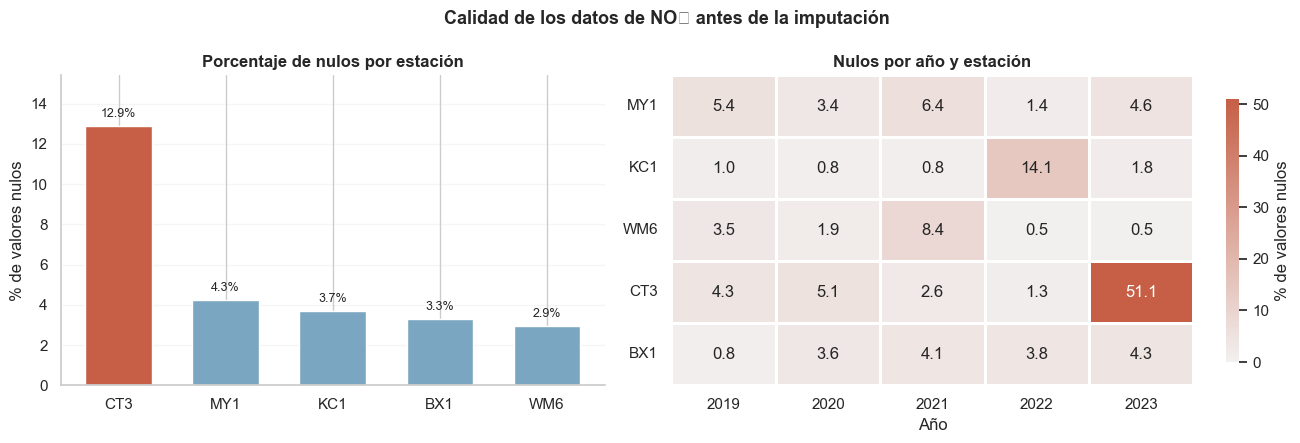

Nulos por estación:
  CT3 (Urban Background    ):  12.9%
  MY1 (Roadside            ):   4.3%
  KC1 (Urban Background    ):   3.7%
  BX1 (Suburban            ):   3.3%
  WM6 (Roadside            ):   2.9%

Nulos tras imputación — NO2: 0
Nulos tras imputación — O3 : 0


In [ ]:
null_pct = no2_raw.isna().mean().mul(100).sort_values(ascending=False)
yearly_null = no2_raw.resample('YE').apply(lambda x: x.isna().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), gridspec_kw={'width_ratios': [1, 1.2]})

bar_colors = ['#c65f46'] + ['#7aa6c2'] * (len(null_pct) - 1)
bars = axes[0].bar(null_pct.index, null_pct.values, color=bar_colors, width=0.62)
axes[0].set_title('Porcentaje de nulos por estación', fontweight='bold')
axes[0].set_ylabel('% de valores nulos')
axes[0].set_xlabel('')
axes[0].set_ylim(0, max(15, null_pct.max() + 2.5))
axes[0].grid(axis='y', alpha=0.18)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, value in zip(bars, null_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value + 0.3,
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(
    yearly_null.T,
    ax=axes[1],
    cmap=sns.light_palette('#c65f46', as_cmap=True),
    vmin=0,
    vmax=float(np.nanmax(yearly_null.to_numpy())),
    annot=True,
    fmt='.1f',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': '% de valores nulos', 'shrink': 0.85}
)
axes[1].set_title('Nulos por año y estación', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Año')
axes[1].set_xticklabels(yearly_null.index.year, rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Calidad de los datos de NO₂ antes de la imputación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_nulos_no2.png', bbox_inches='tight', dpi=160)
plt.show()

print('Nulos por estación:')
for s, pct in null_pct.items():
    print(f'  {s} ({STATION_INFO[s]["type"]:20s}): {pct:5.1f}%')

# Imputación paso 1: interpolación temporal
no2_filled = no2_raw.interpolate(method='time', limit=48)
o3_filled  = o3_raw.interpolate(method='time', limit=48)

# Imputación paso 2: media estacional (hora × mes)
def seasonal_impute(df):
    out = df.copy()
    out['_h'] = out.index.hour
    out['_m'] = out.index.month
    for col in df.columns:
        grp = out.groupby(['_m','_h'])[col].transform('mean')
        out[col] = out[col].fillna(grp)
    return out.drop(columns=['_h','_m'])

no2_filled = seasonal_impute(no2_filled)
o3_filled  = seasonal_impute(o3_filled)

print(f'\nNulos tras imputación — NO2: {no2_filled.isna().sum().sum()}')
print(f'Nulos tras imputación — O3 : {o3_filled.isna().sum().sum()}')

La calidad de los datos es, en general, buena en las cinco estaciones analizadas. La mayoría presentan porcentajes reducidos de valores ausentes, por debajo del 5%, aunque CT3 destaca con un nivel de nulos mayor, especialmente en 2023, donde se concentra la mayor parte de las ausencias.

Dado que los valores ausentes se concentran en periodos concretos y no afectan de igual forma a todas las estaciones, aplicamos una estrategia de imputación en dos etapas:
- interpolación temporal para huecos cortos,
- media estacional para faltantes más largos.

Tras este proceso, el número de nulos se reduce a 0 tanto en NO₂ como en O₃.

### 2.3 Distribuciones y tratamiento de outliers

Analizamos las distribuciones de NO₂ por estación para detectar outliers con el criterio IQR. La línea verde marca el **límite anual OMS de 40 μg/m³** para NO₂.

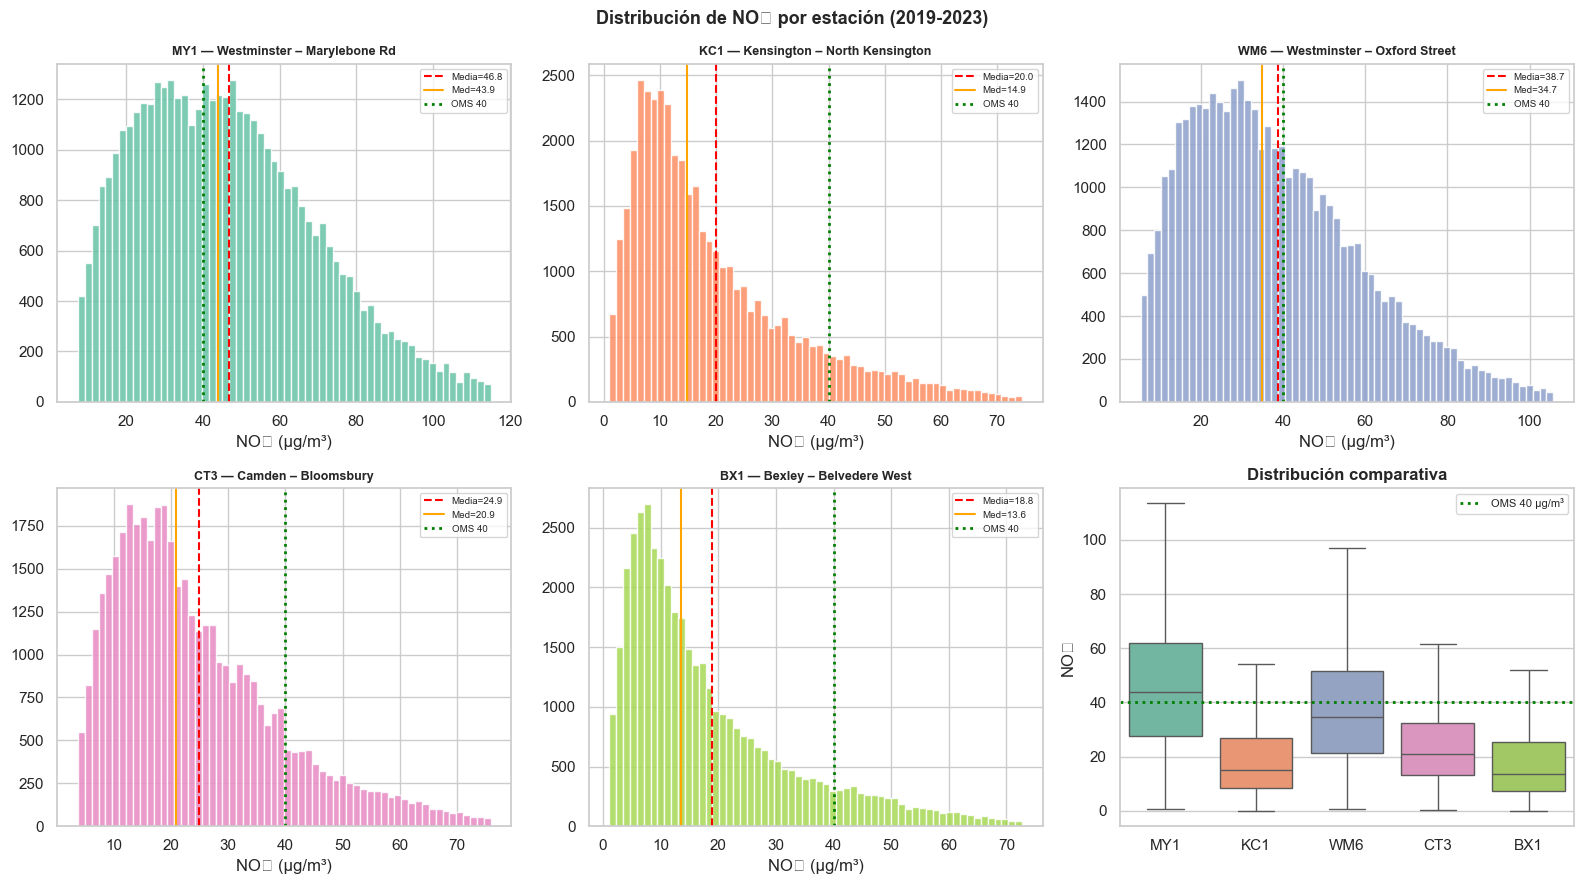

Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR):
  MY1:  450 outliers (1.1%) | rango válido: [-24.9, 114.3]
  KC1: 2159 outliers (5.1%) | rango válido: [-18.8, 53.7]
  WM6:  770 outliers (1.8%) | rango válido: [-24.2, 97.1]
  CT3: 1245 outliers (3.3%) | rango válido: [-17.8, 63.5]
  BX1: 2224 outliers (5.2%) | rango válido: [-19.5, 52.0]


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()
colors = sns.color_palette('Set2', len(STATION_INFO))

for i, (s, info) in enumerate(STATION_INFO.items()):
    data = no2_filled[s]
    q_lo, q_hi = data.quantile(0.01), data.quantile(0.99)
    axes_flat[i].hist(data[(data>=q_lo)&(data<=q_hi)], bins=60,
                      color=colors[i], edgecolor='white', alpha=0.85)
    axes_flat[i].axvline(data.mean(),   color='red',    ls='--',
                         label=f'Media={data.mean():.1f}')
    axes_flat[i].axvline(data.median(), color='orange', ls='-',
                         label=f'Med={data.median():.1f}')
    axes_flat[i].axvline(40, color='green', ls=':', lw=2, label='OMS 40')
    axes_flat[i].set_title(f'{s} — {info["name"]}', fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel('NO₂ (μg/m³)')
    axes_flat[i].legend(fontsize=7)

# Último panel: boxplot comparativo
data_bp = pd.melt(no2_filled.clip(lower=0), var_name='Est.', value_name='NO₂')
sns.boxplot(data=data_bp, x='Est.', y='NO₂', ax=axes_flat[5],
            palette='Set2', showfliers=False)
axes_flat[5].axhline(40, color='green', ls=':', lw=2, label='OMS 40 μg/m³')
axes_flat[5].set_title('Distribución comparativa', fontweight='bold')
axes_flat[5].set_xlabel('')
axes_flat[5].legend(fontsize=8)

plt.suptitle('Distribución de NO₂ por estación (2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_distribuciones.png', bbox_inches='tight')
plt.show()

print('Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR):')
for s in STATION_INFO:
    q1, q3 = no2_raw[s].quantile(0.25), no2_raw[s].quantile(0.75)
    iqr = q3 - q1
    mask = (no2_raw[s] < q1-1.5*iqr) | (no2_raw[s] > q3+1.5*iqr)
    n_out = mask.sum()
    pct = n_out / no2_raw[s].notna().sum() * 100
    print(f'  {s}: {n_out:4d} outliers ({pct:.1f}%) | '
          f'rango válido: [{q1-1.5*iqr:.1f}, {q3+1.5*iqr:.1f}]')

no2_clip = no2_filled.clip(lower=0, upper=no2_filled.quantile(0.995).max())

Las distribuciones de NO₂ muestran diferencias claras entre estaciones. 
- MY1 y WM6, ambas de tipo *roadside*, presentan niveles más altos y una mayor proporción de observaciones cercanas o superiores al umbral anual de la OMS (40 μg/m³)
- KC1, CT3 y BX1 se sitúan en valores generalmente más bajos. 

Es importante fijarse en que en casi todas las estaciones la media supera a la mediana, lo que sugiere distribuciones asimétricas a la derecha, con episodios puntuales de contaminación elevada.


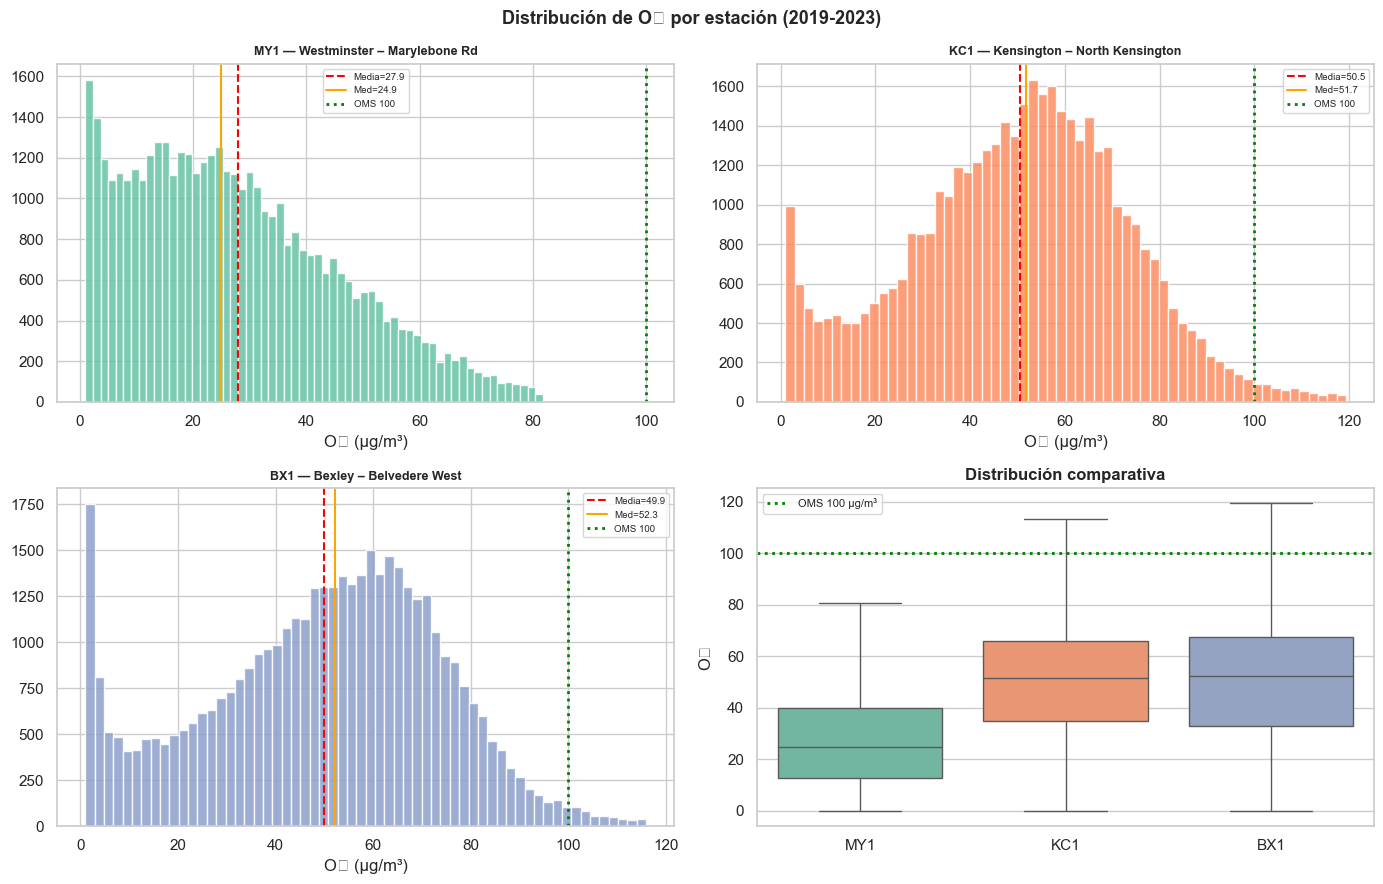

Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR) para O3:
  MY1:  417 outliers (1.0%) | rango válido: [-29.6, 82.4]
  KC1:  530 outliers (1.3%) | rango válido: [-13.1, 114.6]
  BX1:  376 outliers (0.9%) | rango válido: [-19.2, 119.2]


In [ ]:
# Obtenemos solo las estaciones que tienen datos de O3
o3_stations = [s for s in STATION_INFO.keys() if s in o3_filled.columns]

# Como son 3 estaciones + 1 boxplot = 4 paneles, usamos un grid de 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flatten()
colors = sns.color_palette('Set2', len(o3_stations))

# Histogramas por estación
for i, s in enumerate(o3_stations):
    info = STATION_INFO[s]
    data = o3_filled[s]
    q_lo, q_hi = data.quantile(0.01), data.quantile(0.99)
    
    axes_flat[i].hist(data[(data>=q_lo)&(data<=q_hi)], bins=60,
                      color=colors[i], edgecolor='white', alpha=0.85)
    axes_flat[i].axvline(data.mean(),   color='red',    ls='--',
                         label=f'Media={data.mean():.1f}')
    axes_flat[i].axvline(data.median(), color='orange', ls='-',
                         label=f'Med={data.median():.1f}')
    # Límite OMS O3 (suele ser 100 μg/m3)
    axes_flat[i].axvline(100, color='green', ls=':', lw=2, label='OMS 100')
    
    axes_flat[i].set_title(f'{s} — {info["name"]}', fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel('O₃ (μg/m³)')
    axes_flat[i].legend(fontsize=7)

# Último panel (índice -1): boxplot comparativo
data_bp_o3 = pd.melt(o3_filled[o3_stations].clip(lower=0), var_name='Est.', value_name='O₃')
sns.boxplot(data=data_bp_o3, x='Est.', y='O₃', ax=axes_flat[-1],
            palette='Set2', showfliers=False)
axes_flat[-1].axhline(100, color='green', ls=':', lw=2, label='OMS 100 μg/m³')
axes_flat[-1].set_title('Distribución comparativa', fontweight='bold')
axes_flat[-1].set_xlabel('')
axes_flat[-1].legend(fontsize=8)

plt.suptitle('Distribución de O₃ por estación (2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_distribuciones_o3.png', bbox_inches='tight')
plt.show()

# Cálculo e impresión de Outliers
print('Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR) para O3:')
for s in o3_stations:
    q1, q3 = o3_raw[s].quantile(0.25), o3_raw[s].quantile(0.75)
    iqr = q3 - q1
    mask = (o3_raw[s] < q1-1.5*iqr) | (o3_raw[s] > q3+1.5*iqr)
    n_out = mask.sum()
    pct = n_out / o3_raw[s].notna().sum() * 100
    print(f'  {s}: {n_out:4d} outliers ({pct:.1f}%) | '
          f'rango válido: [{q1-1.5*iqr:.1f}, {q3+1.5*iqr:.1f}]')

# Clipping final adaptado a O3
o3_clip = o3_filled.clip(lower=0, upper=o3_filled.quantile(0.995).max())


### 2.4 Red de transporte TfL

Exploramos la distribución geográfica y tipológica de las paradas TfL. La distancia a la parada más cercana es un indicador de accesibilidad al transporte.

Paradas TfL (con coords): 4,084
Columnas: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station']


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,HUBABW-1001001-Bus-5,Bus,51.492376,0.121282,3,HUBABW
1,HUBABW-1001001-EL EB-8,EL EB,51.491282,0.121087,3,HUBABW
2,HUBABW-1001001-EL WB-9,EL WB,51.491219,0.121084,3,HUBABW


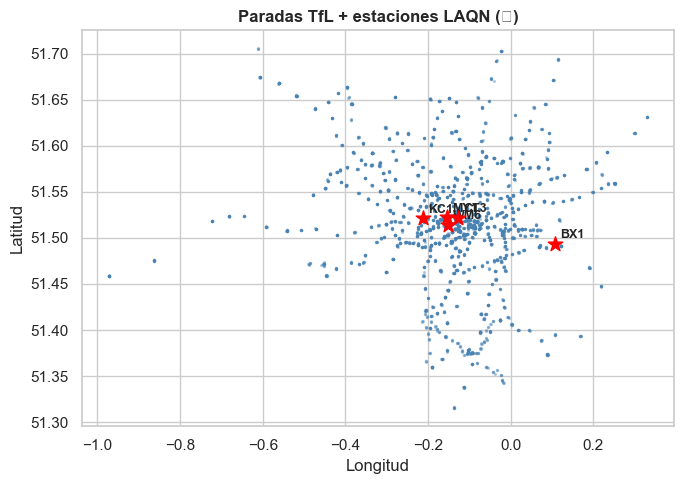

Distancia a parada TfL más cercana:
  MY1: 112 m (BusDE) | 20 paradas ≤500 m
  KC1: 449 m (HamEB) | 6 paradas ≤500 m
  WM6: 199 m (B-GIL) | 43 paradas ≤500 m
  CT3: 162 m (Bus) | 8 paradas ≤500 m
  BX1: 1003 m (FELIX) | 0 paradas ≤500 m


In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

print(f'Paradas TfL (con coords): {len(stops):,}')
print(f'Columnas: {stops.columns.tolist()}')
display(stops.head(3))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(stops['stop_lon'], stops['stop_lat'], alpha=0.3, s=2,
                color='steelblue', label='Paradas TfL')
for s, info in STATION_INFO.items():
    ax.scatter(info['lon'], info['lat'], color='red', s=120,
                    zorder=6, marker='*')
    ax.annotate(s, (info['lon'], info['lat']),
                     textcoords='offset points', xytext=(4,4), fontsize=9, fontweight='bold')
ax.set_title('Paradas TfL + estaciones LAQN (★)', fontweight='bold')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_tfl_geo.png', bbox_inches='tight')
plt.show()

print('Distancia a parada TfL más cercana:')
for s, info in STATION_INFO.items():
    dists = haversine(info['lat'], info['lon'],
                      stops['stop_lat'].values, stops['stop_lon'].values)
    idx = np.argmin(dists)
    n500 = int((dists<=500).sum())
    print(f'  {s}: {dists[idx]:.0f} m ({stops.iloc[idx]["stop_name"]}) | {n500} paradas ≤500 m')

# ── Mapa interactivo — Paradas TfL y estaciones LAQN ──────
map_tfl_mc = folium.Map(location=[51.505, -0.105], zoom_start=11,
                        tiles='CartoDB positron')
for _, row in stops.head(500).iterrows():  # Usar stops en lugar de gtfs_stations, y aumentar a 500
    if pd.notna(row['stop_lat']) and pd.notna(row['stop_lon']):
        folium.Marker(
            location=[row['stop_lat'], row['stop_lon']],
            popup=str(row['stop_name'])[:50],
            icon=folium.Icon(color='blue', icon='train', prefix='fa')
        ).add_to(map_tfl_mc)
for s, info in STATION_INFO.items():
    folium.Marker(
        location=[info['lat'], info['lon']],
        popup=f'{s} - {info["name"]}',
        icon=folium.Icon(color='red', icon='cloud', prefix='fa'),
        tooltip=s
    ).add_to(map_tfl_mc)
map_tfl_mc

## 3. Análisis de contaminación del aire <a id='3'></a>

Para este punto hemos seguido la metodología del laboratorio de contaminación ambiental. Hemos analizado la estacionalidad mediante boxplots (percentil 95), tendencia interanual con ventana deslizante anual y hemos hecho una comparativa entre estaciones.

### 3.1 Estacionalidad: patrones horarios y estacionales

Cuatro boxplots filtrados al percentil 95:
- **Semanal NO₂**: diferencia laborable/fin de semana.
- **Mensual NO₂**: patrón estacional invierno/verano.
- **Horario NO₂**: doble pico rush-hour (8h y 18h).
- **Semanal O₃**: patrón inverso al NO₂ (química troposférica).

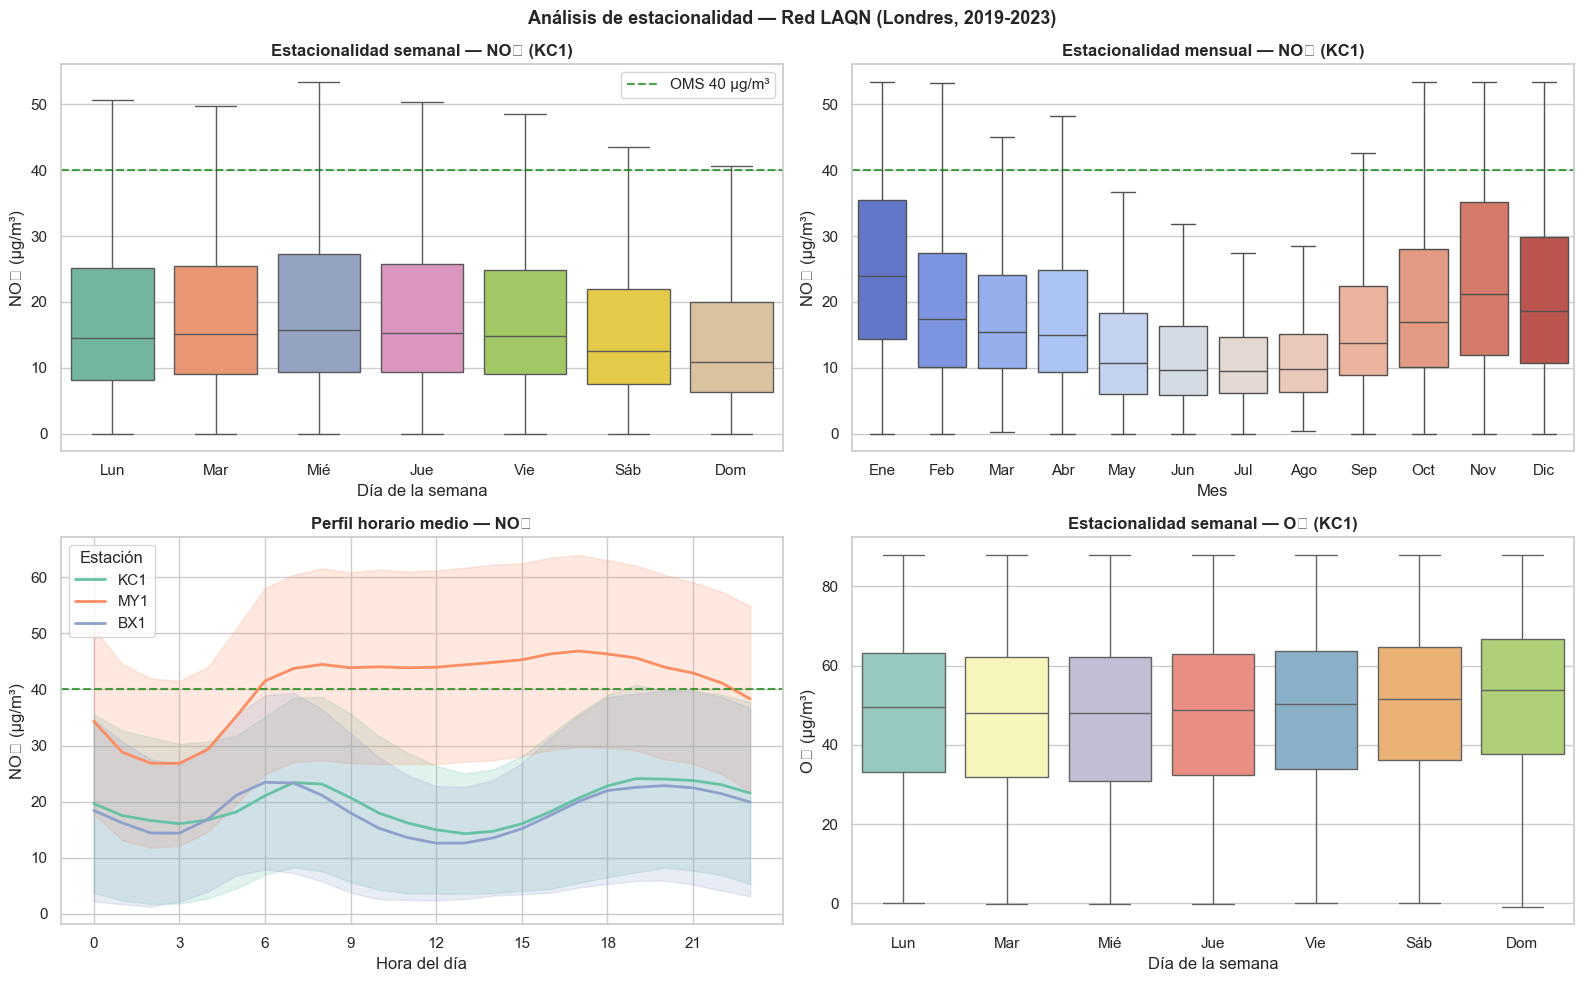

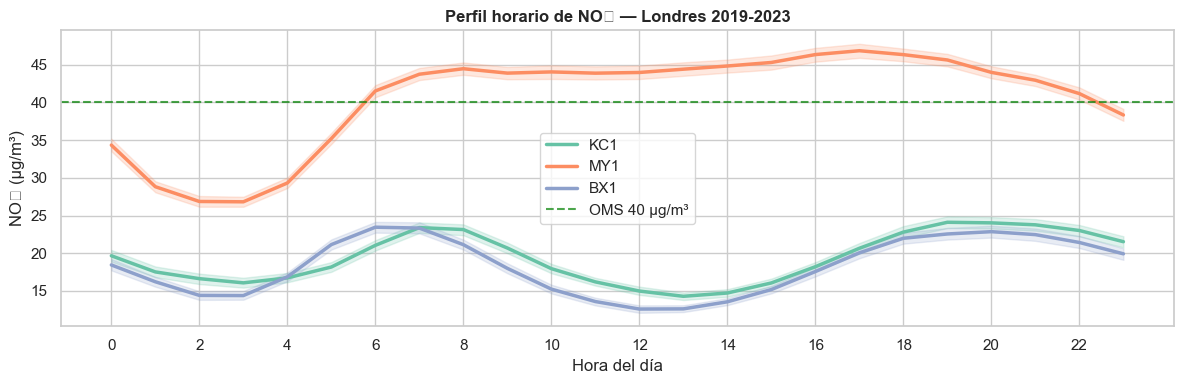

In [ ]:
df_kc1 = no2_clip[['KC1']].copy()
df_kc1.columns = ['NO2']
df_kc1['hora'] = df_kc1.index.hour
df_kc1['dia']  = df_kc1.index.dayofweek
df_kc1['mes']  = df_kc1.index.month

p95 = df_kc1['NO2'].quantile(0.95)
df_plot = df_kc1[df_kc1['NO2'] <= p95].copy()

nombres_dias  = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}
nombres_meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                 7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df_plot['dia_str'] = df_plot['dia'].map(nombres_dias)
df_plot['mes_str'] = df_plot['mes'].map(nombres_meses)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
orden_dias  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

sns.boxplot(data=df_plot, x='dia_str', y='NO2', order=orden_dias,
            ax=axes[0,0], palette='Set2', showfliers=False)
axes[0,0].axhline(40, color='green', ls='--', alpha=0.7, label='OMS 40 μg/m³')
axes[0,0].set_title('Estacionalidad semanal — NO₂ (KC1)', fontweight='bold')
axes[0,0].set_xlabel('Día de la semana'); axes[0,0].set_ylabel('NO₂ (μg/m³)')
axes[0,0].legend()

sns.boxplot(data=df_plot, x='mes_str', y='NO2', order=orden_meses,
            ax=axes[0,1], palette='coolwarm', showfliers=False)
axes[0,1].axhline(40, color='green', ls='--', alpha=0.7)
axes[0,1].set_title('Estacionalidad mensual — NO₂ (KC1)', fontweight='bold')
axes[0,1].set_xlabel('Mes'); axes[0,1].set_ylabel('NO₂ (μg/m³)')

df_hora = no2_clip[['KC1','MY1','BX1']].copy()
df_hora['hora'] = df_hora.index.hour
df_melt = pd.melt(df_hora, id_vars=['hora'],
                  value_vars=['KC1','MY1','BX1'], var_name='Estación', value_name='NO₂')
df_melt = df_melt[df_melt['NO₂'] <= df_melt['NO₂'].quantile(0.95)]
sns.lineplot(data=df_melt, x='hora', y='NO₂', hue='Estación',
             ax=axes[1,0], estimator='mean', errorbar='sd', linewidth=2)
axes[1,0].axhline(40, color='green', ls='--', alpha=0.7)
axes[1,0].set_title('Perfil horario medio — NO₂', fontweight='bold')
axes[1,0].set_xlabel('Hora del día'); axes[1,0].set_ylabel('NO₂ (μg/m³)')
axes[1,0].set_xticks(range(0,24,3))

df_o3 = o3_filled[['KC1']].copy(); df_o3.columns = ['O3']
df_o3['dia_str'] = df_o3.index.dayofweek.map(nombres_dias)
df_o3_filt = df_o3[df_o3['O3'] <= df_o3['O3'].quantile(0.95)]
sns.boxplot(data=df_o3_filt, x='dia_str', y='O3', order=orden_dias,
            ax=axes[1,1], palette='Set3', showfliers=False)
axes[1,1].set_title('Estacionalidad semanal — O₃ (KC1)', fontweight='bold')
axes[1,1].set_xlabel('Día de la semana'); axes[1,1].set_ylabel('O₃ (μg/m³)')

plt.suptitle('Análisis de estacionalidad — Red LAQN (Londres, 2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_estacionalidad.png', bbox_inches='tight')
plt.show()

# Perfil horario independiente para el dashboard
fig2, ax2 = plt.subplots(figsize=(12, 4))
sns.lineplot(data=df_melt, x='hora', y='NO₂', hue='Estación',
             ax=ax2, estimator='mean', linewidth=2.5)
ax2.axhline(40, color='green', ls='--', alpha=0.7, label='OMS 40 μg/m³')
ax2.set_title('Perfil horario de NO₂ — Londres 2019-2023', fontweight='bold')
ax2.set_xlabel('Hora del día'); ax2.set_ylabel('NO₂ (μg/m³)')
ax2.set_xticks(range(0,24,2)); ax2.legend()
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_hora_no2.png', bbox_inches='tight')
plt.show()

El análisis de estacionalidad muestra patrones temporales claros en la concentración de NO₂. A escala semanal, los niveles tienden a ser algo mayores en días laborables que en fin de semana, mientras que a escala mensual se observa una mayor concentración en los meses fríos y una reducción en verano. En el perfil horario aparece el patrón más marcado: un incremento en las horas punta de la mañana y de la tarde, especialmente en la estación *roadside* MY1, lo que sugiere una fuerte influencia del tráfico urbano. Por contraste, el O₃ presenta un comportamiento semanal más estable y, en general, opuesto al NO₂.


### 3.2 Tendencia interanual

La ventana deslizante anual (8 760 horas) nos permite suavizar la estacionalidad y muestra la tendencia a largo plazo, incluyendo la **reducción de NO₂ durante el confinamiento COVID-19 (marzo–julio 2020)**.

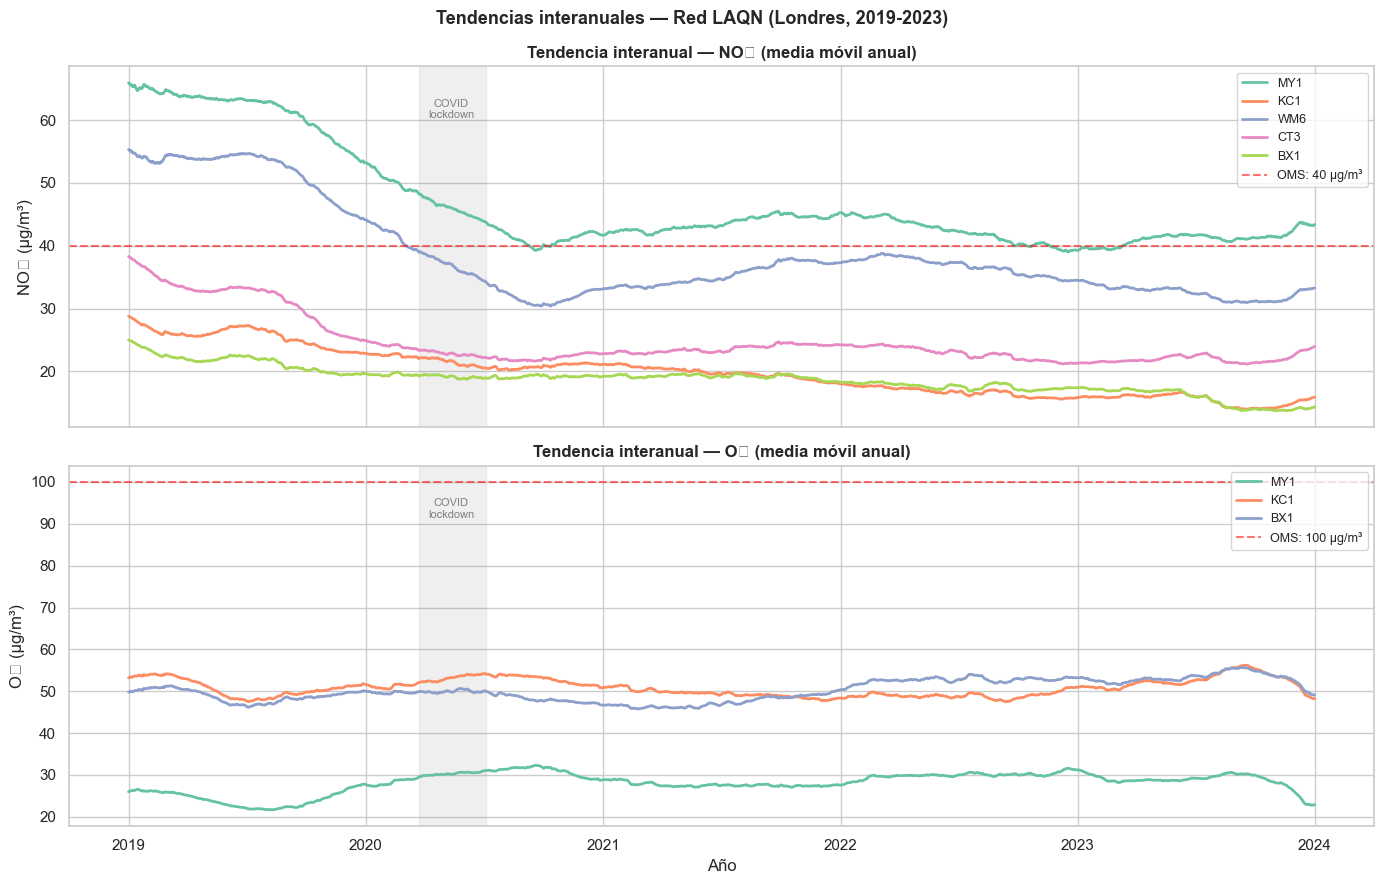

In [ ]:
ventana = 365 * 24

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
colors = sns.color_palette('Set2', len(STATION_INFO))

for ax, pollutant, data, oms_limit in [
    (axes[0], 'NO₂', no2_filled, 40),
    (axes[1], 'O₃',  o3_filled,  100),
]:
    for i, s in enumerate(data.columns):
        mm = data[s].rolling(window=ventana, center=True, min_periods=ventana//8).mean()
        ax.plot(mm.index, mm, linewidth=2, color=colors[i], label=s)
    ax.axhline(oms_limit, color='red', ls='--', alpha=0.55,
               label=f'OMS: {oms_limit} μg/m³')
    ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2020-07-04'),
               alpha=0.12, color='gray')
    # Obtener ylim después de dibujar las líneas
    ylim_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 60
    ax.text(pd.Timestamp('2020-05-12'), ylim_top * 0.88,
            'COVID\nlockdown', fontsize=8, color='gray', ha='center')
    ax.set_title(f'Tendencia interanual — {pollutant} (media móvil anual)',
                 fontweight='bold')
    ax.set_ylabel(f'{pollutant} (μg/m³)')
    ax.legend(fontsize=9, loc='upper right')

axes[1].set_xlabel('Año')
plt.suptitle('Tendencias interanuales — Red LAQN (Londres, 2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_tendencia.png', bbox_inches='tight')
plt.show()

### 3.3 Comparativa entre estaciones

El mapa de calor de la media anual permite comparar simultáneamente la evolución temporal y las diferencias espaciales.

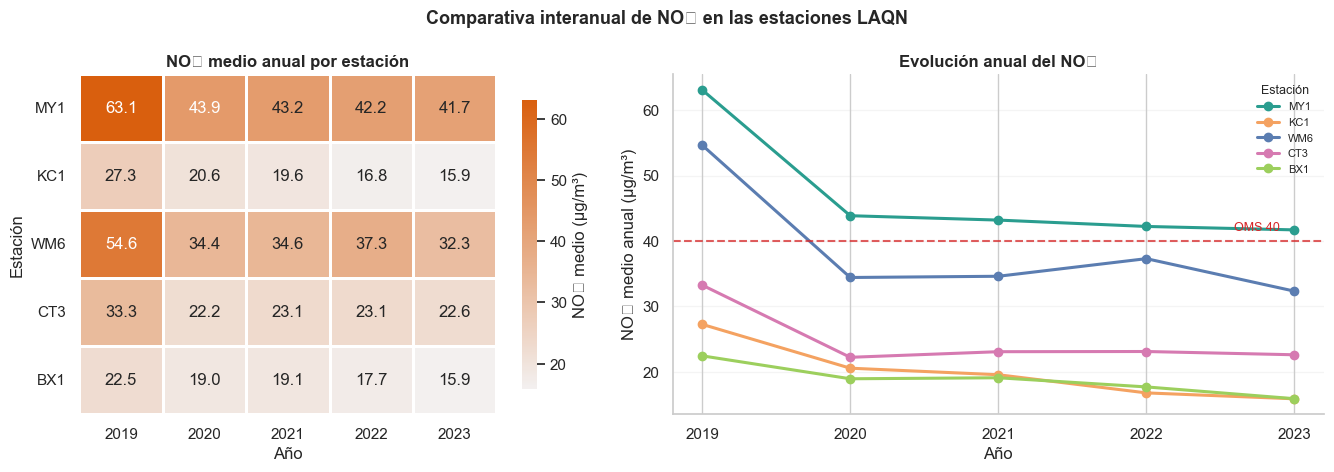

NO₂ medio 2019-2023 (μg/m³):
  MY1: 46.81  excede OMS
  KC1: 20.03  ✓ bajo OMS
  WM6: 38.66  ✓ bajo OMS
  CT3: 24.87  ✓ bajo OMS
  BX1: 18.83  ✓ bajo OMS


In [ ]:
annual_no2 = no2_filled.resample('YE').mean()
annual_no2.index = annual_no2.index.year

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={'width_ratios': [1, 1.25]})

sns.heatmap(
    annual_no2.T,
    ax=axes[0],
    cmap=sns.light_palette('#d95f0e', as_cmap=True),
    annot=True,
    fmt='.1f',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'NO₂ medio (μg/m³)', 'shrink': 0.85}
)
axes[0].set_title('NO₂ medio anual por estación', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Estación')
axes[0].set_xticklabels(annual_no2.index.astype(str), rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

colors_c = {'MY1':'#2a9d8f', 'KC1':'#f4a261', 'WM6':'#5b7db1', 'CT3':'#d67ab1', 'BX1':'#9ccf5d'}
for s in STATION_INFO.keys():
    axes[1].plot(
        annual_no2.index, annual_no2[s], marker='o', markersize=6,
        lw=2.2, color=colors_c[s], label=s
    )
axes[1].axhline(40, color='#d62728', ls='--', lw=1.5, alpha=0.75)
axes[1].text(annual_no2.index[-1] - 0.1, 41.2, 'OMS 40', color='#d62728',
             ha='right', va='bottom', fontsize=9)
axes[1].set_title('Evolución anual del NO₂', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('NO₂ medio anual (μg/m³)')
axes[1].set_xticks(annual_no2.index)
axes[1].grid(axis='y', alpha=0.2)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(title='Estación', fontsize=8, title_fontsize=9, frameon=False, loc='upper right')

plt.suptitle('Comparativa interanual de NO₂ en las estaciones LAQN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_comparacion.png', bbox_inches='tight', dpi=160)
plt.show()

mean_no2_by_station = no2_filled.mean()
print('NO₂ medio 2019-2023 (μg/m³):')
for s, val in mean_no2_by_station.items():
    oms = 'excede OMS' if val > 40 else '✓ bajo OMS'
    print(f'  {s}: {val:.2f}  {oms}')

La comparación interanual muestra una reducción clara de los niveles medios de NO₂ entre 2019 y 2023 en la mayoría de estaciones. MY1 y WM6, ambas de tipo *roadside*, mantienen los valores más altos durante todo el periodo, mientras que KC1, CT3 y BX1 se sitúan en niveles más bajos y por debajo del umbral anual de la OMS.

## 4. Análisis de movilidad urbana <a id='4'></a>

Construimos un **grafo de red TfL** desde el fichero GTFS `pathways.txt` y analizamos la distribución de las paradas.

### 4.1 Grafo de la red TfL (RQ4-B)

Cada nodo es una parada; cada arista es una conexión peatonal. Calculamos métricas de centralidad.

Nodos       : 4,529
Aristas     : 5,036
Componentes : 793
Densidad    : 0.000491
Top 10 nodos por centralidad de grado:
  RPL                                           0.2297
  Bus                                           0.1486
  Outside King's Cross St Pancras               0.1486
  EntrS                                         0.1216
  BCQ                                           0.1216
  Conc                                          0.1081
  PentE                                         0.0946
  I-E/C                                         0.0946
  WTH                                           0.0811
  NPE                                           0.0676


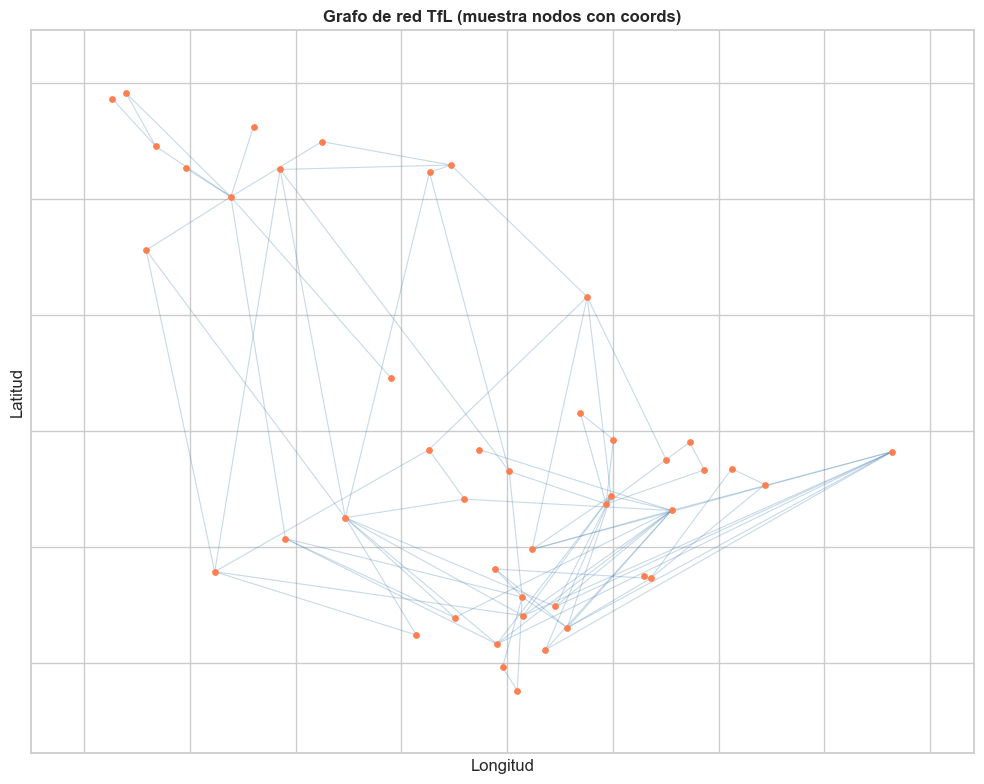

In [ ]:
G = nx.from_pandas_edgelist(
    gtfs_pathways,
    source='from_stop_id',
    target='to_stop_id',
    create_using=nx.Graph()
)

gtfs_w_coords = gtfs_stops.dropna(subset=['stop_lat','stop_lon'])
pos_dict = {row['stop_id']: (row['stop_lon'], row['stop_lat'])
            for _, row in gtfs_w_coords.iterrows()}

print(f'Nodos       : {G.number_of_nodes():,}')
print(f'Aristas     : {G.number_of_edges():,}')
print(f'Componentes : {nx.number_connected_components(G)}')
print(f'Densidad    : {nx.density(G):.6f}')

largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()
deg_cent = nx.degree_centrality(G_main)
top10 = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print('Top 10 nodos por centralidad de grado:')
for nid, cent in top10:
    row = gtfs_stops[gtfs_stops['stop_id'] == nid]
    name = row['stop_name'].iloc[0] if len(row) > 0 else nid[:30]
    print(f'  {str(name):45s} {cent:.4f}')

# Solo nodos con posicion conocida
sample = [n for n in list(G_main.nodes)[:400] if n in pos_dict]
G_vis = G_main.subgraph(sample)
pos_vis = {n: pos_dict[n] for n in G_vis.nodes if n in pos_dict}
valid_edges = [(u,v) for u,v in G_vis.edges() if u in pos_vis and v in pos_vis]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=valid_edges,
                       alpha=0.3, width=0.8, edge_color='steelblue', ax=ax)
nx.draw_networkx_nodes(G_vis, pos_vis, node_size=15, node_color='coral', ax=ax)
ax.set_title('Grafo de red TfL (muestra nodos con coords)', fontweight='bold')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.axis('on')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_grafo_tfl.png', bbox_inches='tight')
plt.show()


### 4.2 Densidad y cobertura de paradas

Analizamos cuántas paradas TfL hay en distintos radios alrededor de cada estación LAQN.

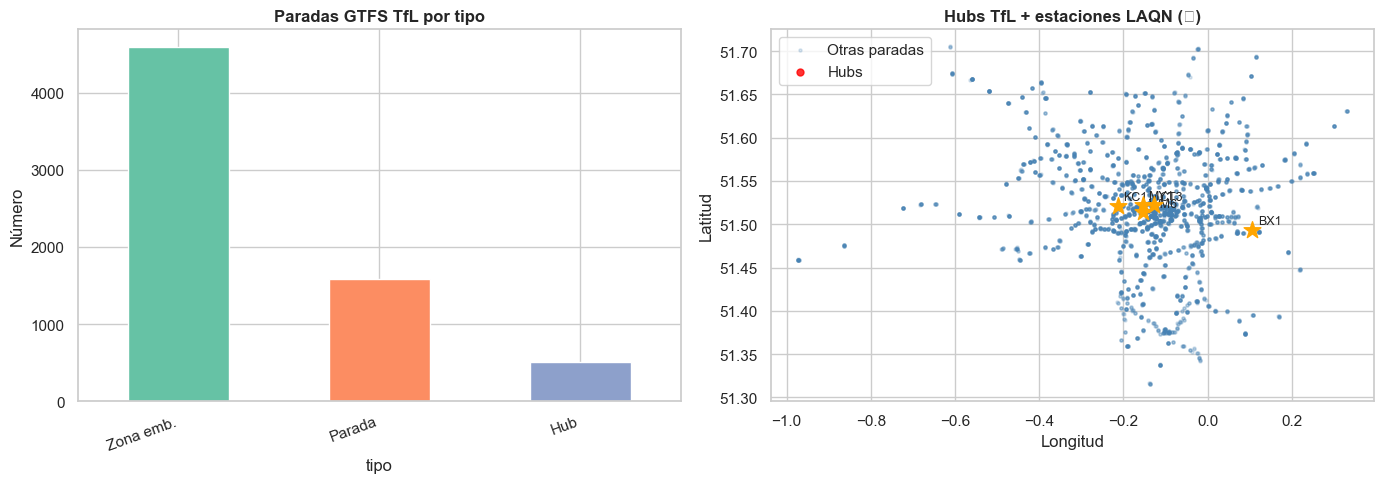

,Tipo,≤200m,≤500m,≤1km
Estación,,,,
MY1,Roadside,12,20,64
KC1,Urban Background,0,6,18
WM6,Roadside,1,43,79
CT3,Urban Background,1,8,107
BX1,Suburban,0,0,0


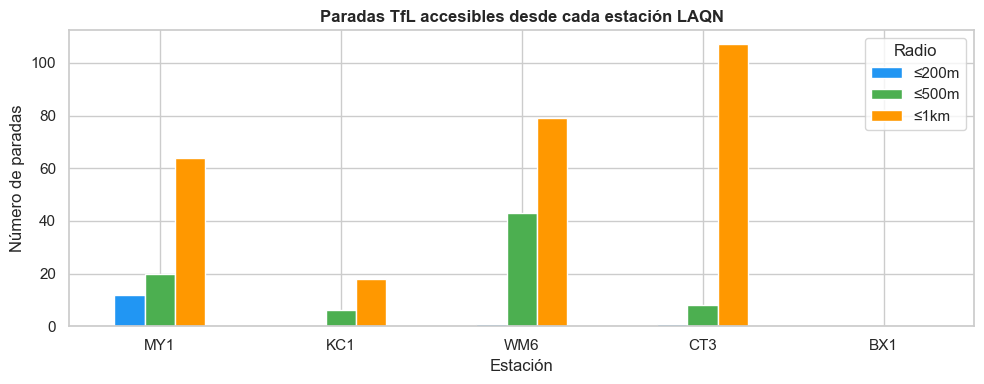

In [ ]:
lt_map2 = {0:'Parada', 1:'Hub', 2:'Entrada', 3:'Zona emb.'}
gtfs_stops['tipo'] = gtfs_stops['location_type'].map(lt_map2).fillna('Otro')
tipo_counts = gtfs_stops['tipo'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tipo_counts.plot(kind='bar', ax=axes[0],
                 color=sns.color_palette('Set2', len(tipo_counts)), edgecolor='white')
axes[0].set_title('Paradas GTFS TfL por tipo', fontweight='bold')
axes[0].set_ylabel('Número')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

hubs  = gtfs_stops[gtfs_stops['location_type']==1].dropna(subset=['stop_lat','stop_lon'])
otras = gtfs_stops[gtfs_stops['location_type']!=1].dropna(subset=['stop_lat','stop_lon'])
axes[1].scatter(otras['stop_lon'], otras['stop_lat'], alpha=0.2, s=5,
                color='steelblue', label='Otras paradas')
axes[1].scatter(hubs['stop_lon'],  hubs['stop_lat'],  alpha=0.8, s=25,
                color='red', label='Hubs')
for s, info in STATION_INFO.items():
    axes[1].scatter(info['lon'], info['lat'], color='orange', s=160,
                    marker='*', zorder=10)
    axes[1].annotate(s, (info['lon'], info['lat']),
                     textcoords='offset points', xytext=(4,4), fontsize=9)
axes[1].set_title('Hubs TfL + estaciones LAQN (★)', fontweight='bold')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_tfl_tipos.png', bbox_inches='tight')
plt.show()

cov_data = []
for s, info in STATION_INFO.items():
    dists = haversine(info['lat'], info['lon'],
                      stops['stop_lat'].values, stops['stop_lon'].values)
    cov_data.append({'Estación': s, 'Tipo': info['type'],
                     '≤200m': int((dists<=200).sum()),
                     '≤500m': int((dists<=500).sum()),
                     '≤1km':  int((dists<=1000).sum())})
df_cov = pd.DataFrame(cov_data).set_index('Estación')
display(df_cov)

df_cov[['≤200m','≤500m','≤1km']].plot(kind='bar', figsize=(10, 4),
    color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
plt.title('Paradas TfL accesibles desde cada estación LAQN', fontweight='bold')
plt.ylabel('Número de paradas')
plt.xticks(rotation=0)
plt.legend(title='Radio')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_cobertura.png', bbox_inches='tight')
plt.show()

### 4.3 Densidad de paradas en hexágonos H3

Siguiendo la metodología del laboratorio de movilidad usamos la librería **H3** (Uber) para agregar las paradas TfL en una malla hexagonal de resolución 9 y visualizar la densidad espacial de transporte sobre Londres.

In [ ]:
# Agregación de paradas TfL por hexágono H3 — igual que en lab_movilidad con NYC taxi
resolution = 9
stops_h3_df = stops[['stop_lat','stop_lon']].copy()
stops_h3_df['count'] = 1

# geo_to_h3_aggregate: cuenta paradas por hexágono
stops_h3 = stops_h3_df.h3.geo_to_h3_aggregate(
    resolution, lat_col='stop_lat', lng_col='stop_lon'
)
print(f'Hexagonos H3 con paradas TfL: {len(stops_h3)}')
print(f'Media de paradas por hexagono: {stops_h3["count"].mean():.2f}')
print(f'Maximo de paradas en un hexagono: {stops_h3["count"].max()}')

# Mapa cloropletico H3 con explore() — mismo patron que lab_movilidad
map_h3 = folium.Map(location=[51.505, -0.105], zoom_start=11,
                    tiles='CartoDB positron')

stops_h3.h3.h3_to_geo_boundary().explore(
    column='count',
    cmap='YlOrRd',
    tooltip=['count'],
    popup=['count'],
    legend=True,
    style_kwds={'fillOpacity': 0.6, 'weight': 1},
    m=map_h3
)

# Estaciones LAQN como marcadores rojos
for s, info in STATION_INFO.items():
    val = round(float(no2_filled[s].mean()), 1)
    folium.Marker(
        location=[info['lat'], info['lon']],
        popup=f'<b>{s}</b><br>{info["name"]}<br>NO2 medio: {val} ug/m3',
        icon=folium.Icon(color='red', icon='cloud', prefix='fa'),
        tooltip=f'{s}: {val} ug/m3'
    ).add_to(map_h3)

map_h3.save(f'{DASH_DIR}/maps/mapa_h3_stops.html')
print('Mapa H3 guardado.')
map_h3


Hexagonos H3 con paradas TfL: 789
Media de paradas por hexagono: 5.18
Maximo de paradas en un hexagono: 29
Mapa H3 guardado.


## 5. Integración movilidad: contaminación <a id='5'></a>

Cruzamos series temporales de calidad del aire con información de cobertura de transporte.

### 5.1 Descomposición estacional

Aplicamos descomposición STL aditiva sobre la serie diaria de NO₂ en KC1.

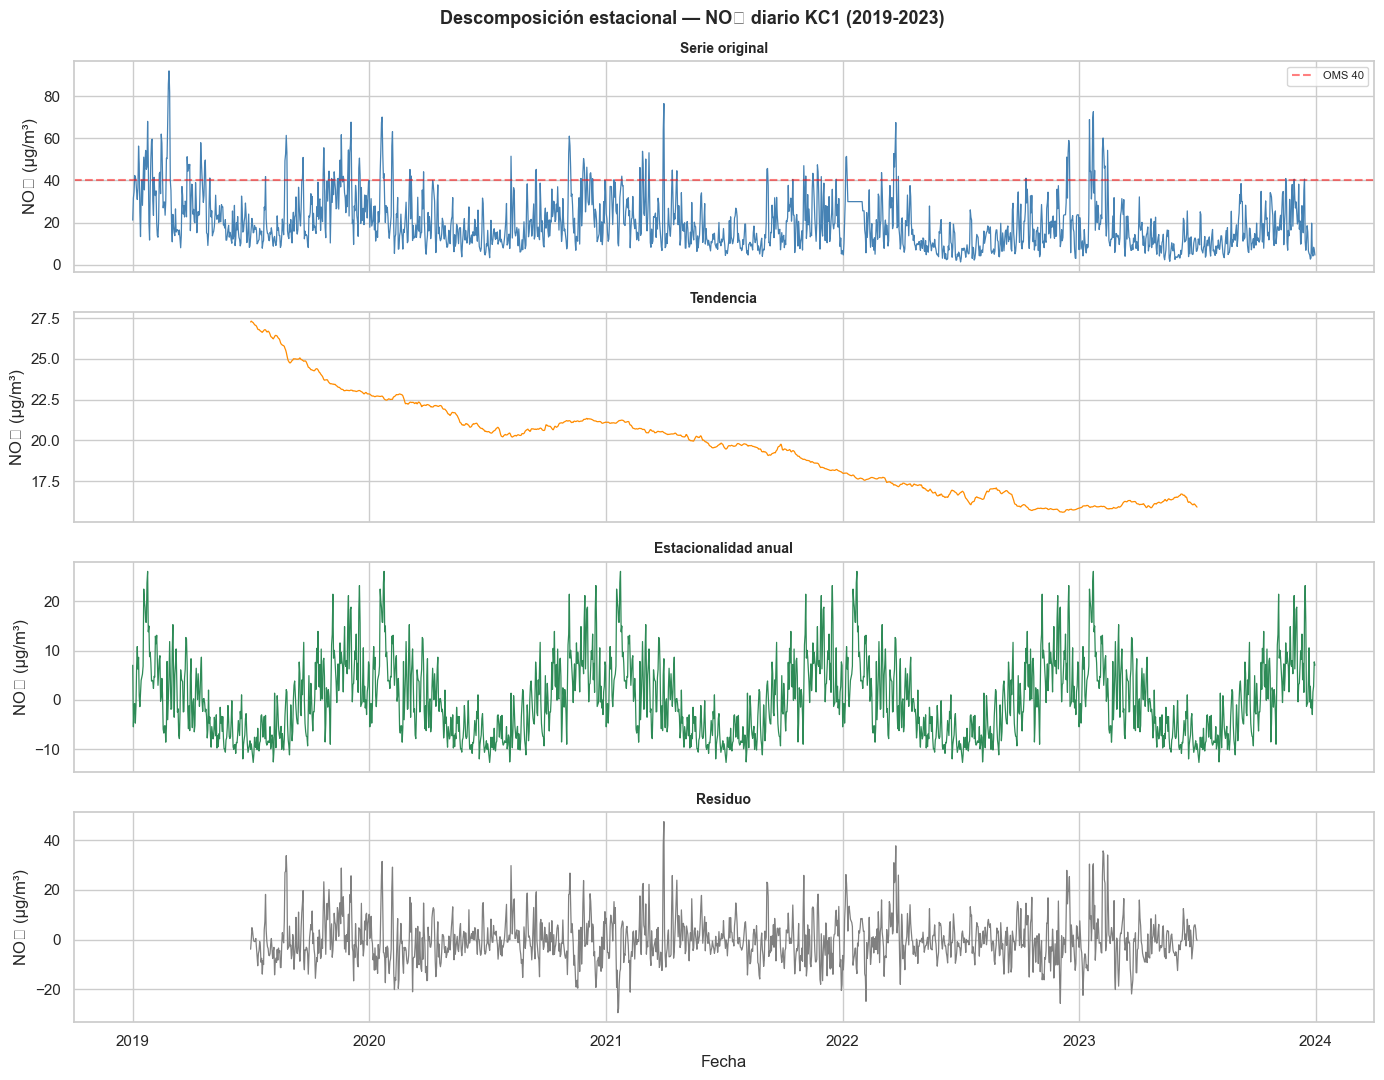

In [ ]:
no2_daily = no2_filled['KC1'].resample('D').mean().dropna()
decomp = seasonal_decompose(no2_daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for ax, (title, series, color) in zip(axes, [
    ('Serie original',       decomp.observed, 'steelblue'),
    ('Tendencia',            decomp.trend,    'darkorange'),
    ('Estacionalidad anual', decomp.seasonal, 'seagreen'),
    ('Residuo',              decomp.resid,    'gray'),
]):
    ax.plot(series, lw=0.9, color=color)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('NO₂ (μg/m³)')
    if title == 'Serie original':
        ax.axhline(40, color='red', ls='--', alpha=0.5, label='OMS 40')
        ax.legend(fontsize=8)
axes[-1].set_xlabel('Fecha')
plt.suptitle('Descomposición estacional — NO₂ diario KC1 (2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_decompose.png', bbox_inches='tight')
plt.show()

### 5.2 Correlación movilidad-contaminación

Para cada estación LAQN calculamos el NO₂ medio y el número de paradas TfL en radio 500 m. También analizamos la correlación entre estaciones.

,Estación,Tipo,NO₂ medio (μg/m³),Paradas ≤500m,Paradas ≤200m
0,MY1,Roadside,46.81,20,12
1,KC1,Urban Background,20.03,6,0
2,WM6,Roadside,38.66,43,1
3,CT3,Urban Background,24.87,8,1
4,BX1,Suburban,18.83,0,0


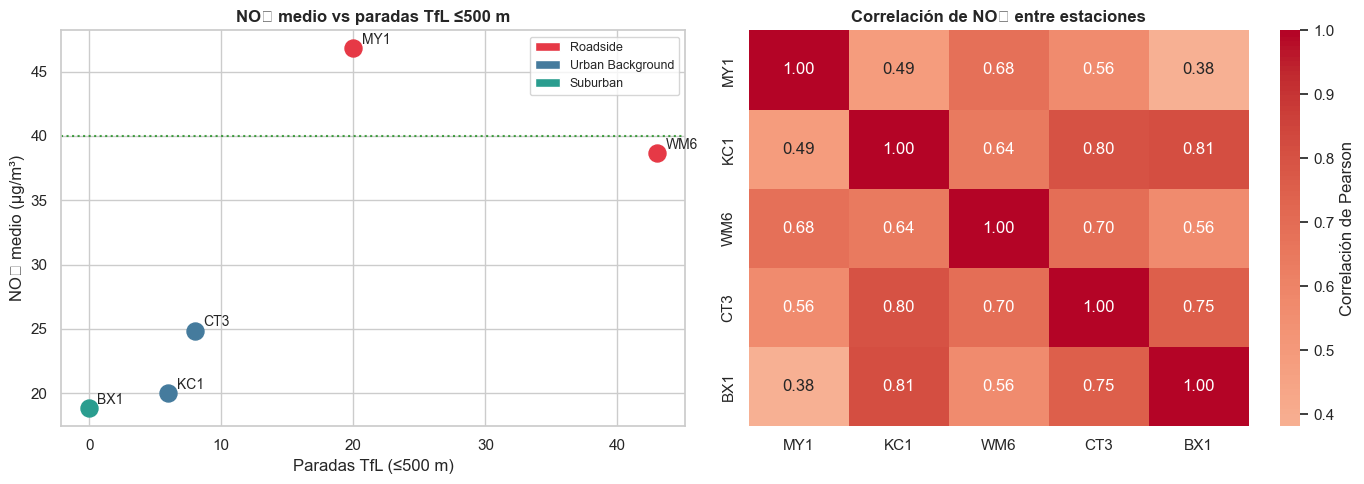

In [ ]:
station_data = []
for s, info in STATION_INFO.items():
    dists = haversine(info['lat'], info['lon'],
                      stops['stop_lat'].values, stops['stop_lon'].values)
    station_data.append({
        'Estación': s, 'Tipo': info['type'],
        'NO₂ medio (μg/m³)': round(float(no2_filled[s].mean()), 2),
        'Paradas ≤500m': int((dists<=500).sum()),
        'Paradas ≤200m': int((dists<=200).sum()),
    })
df_movcont = pd.DataFrame(station_data)
display(df_movcont)

colors_type = {'Roadside':'#e63946', 'Urban Background':'#457b9d', 'Suburban':'#2a9d8f'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for _, row in df_movcont.iterrows():
    axes[0].scatter(row['Paradas ≤500m'], row['NO₂ medio (μg/m³)'],
                    color=colors_type.get(row['Tipo'],'gray'), s=150, zorder=5)
    axes[0].annotate(row['Estación'],
                     (row['Paradas ≤500m'], row['NO₂ medio (μg/m³)']),
                     textcoords='offset points', xytext=(6,3), fontsize=10)

from matplotlib.patches import Patch
leg = [Patch(facecolor=c, label=t) for t, c in colors_type.items()]
axes[0].legend(handles=leg, fontsize=9)
axes[0].set_title('NO₂ medio vs paradas TfL ≤500 m', fontweight='bold')
axes[0].set_xlabel('Paradas TfL (≤500 m)')
axes[0].set_ylabel('NO₂ medio (μg/m³)')
axes[0].axhline(40, color='green', ls=':', alpha=0.7)

sns.heatmap(no2_filled.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], cbar_kws={'label':'Correlación de Pearson'})
axes[1].set_title('Correlación de NO₂ entre estaciones', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_correlacion.png', bbox_inches='tight')
plt.show()

## 6. Modelos predictivos <a id='6'></a>

Dos modelos complementarios:
- **XGBoost**: predicción horaria de NO₂ con variables temporales.
- **Proceso Gaussiano (GP)**: predicción semanal autoregresiva (k=5).

### 6.1 XGBoost: predicción de NO₂

Dataset con las 5 estaciones. Features: hora, día, mes, año, fin de semana y tipo de estación.

Train: 175,296 muestras | Test: 43,824 muestras


,Modelo,MAE,RMSE,R²
0,XGBoost,11.294,14.358,0.1930
1,Gradient Boosting,11.488,14.572,0.1688
2,Árbol decisión,12.113,15.294,0.0844
3,Random Forest,12.115,15.276,0.0865
4,Regresión lineal,17.371,23.153,-1.0986
5,Ridge α=1,17.371,23.153,-1.0985


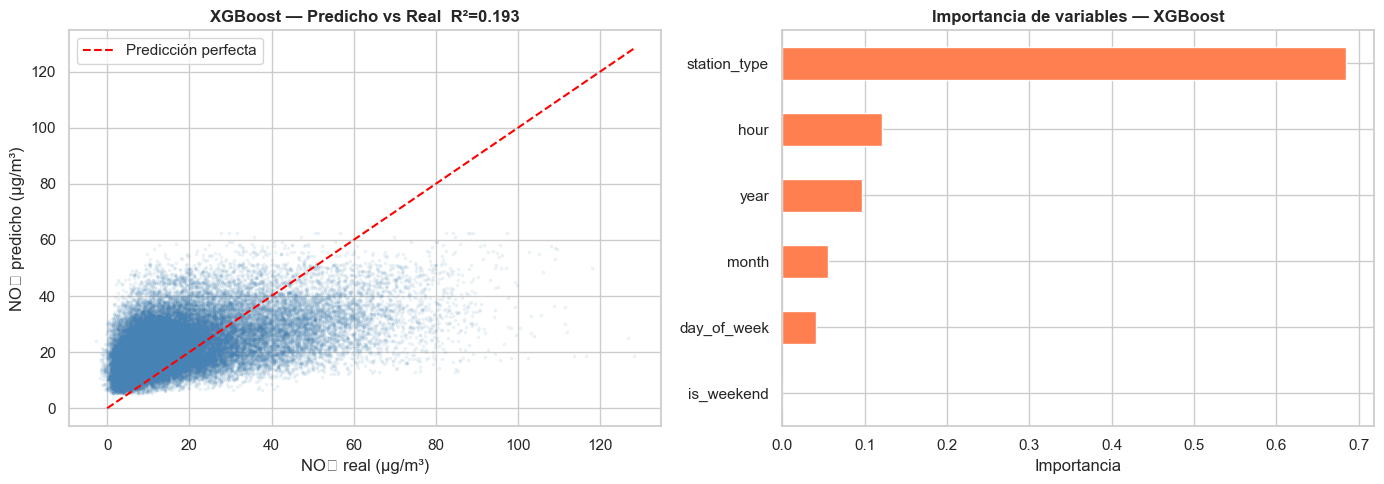

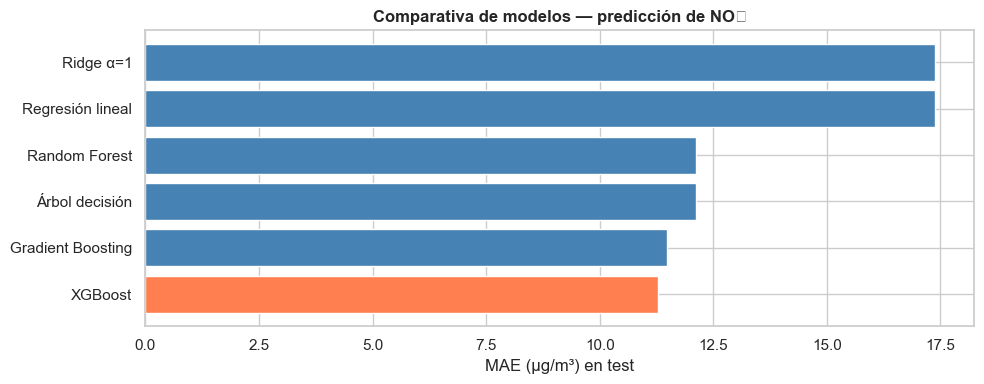

XGBoost → MAE: 11.294 μg/m³ | R²: 0.1930


In [ ]:
TYPE_ENC = {'Roadside': 2, 'Urban Background': 1, 'Suburban': 0}
frames = []
for s, info in STATION_INFO.items():
    df_s = no2_filled[[s]].copy()
    df_s.columns = ['NO2']
    df_s['hour']         = df_s.index.hour
    df_s['day_of_week']  = df_s.index.dayofweek
    df_s['month']        = df_s.index.month
    df_s['year']         = df_s.index.year - 2019
    df_s['is_weekend']   = (df_s.index.dayofweek >= 5).astype(int)
    df_s['station_type'] = TYPE_ENC[info['type']]
    frames.append(df_s.dropna())
df_ml = pd.concat(frames)
FEATURES = ['hour','day_of_week','month','year','is_weekend','station_type']
X = df_ml[FEATURES]
y = df_ml['NO2']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)
print(f'Train: {len(X_train):,} muestras | Test: {len(X_test):,} muestras')

models_dict = {
    'Regresión lineal':  LinearRegression(),
    'Ridge α=1':         Ridge(alpha=1.0),
    'Árbol decisión':    DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=6,
                                               n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                    learning_rate=0.1, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=200, max_depth=5,
                                      learning_rate=0.1, random_state=42, verbosity=0),
}
results_list = []
for name, model in models_dict.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    results_list.append({'Modelo': name,
                          'MAE':  round(mean_absolute_error(y_test, yp), 3),
                          'RMSE': round(float(np.sqrt(mean_squared_error(y_test, yp))), 3),
                          'R²':   round(r2_score(y_test, yp), 4)})
results_df = pd.DataFrame(results_list).sort_values('MAE').reset_index(drop=True)
display(results_df)

xgb_model   = models_dict['XGBoost']
y_pred_xgb  = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2  = r2_score(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test.values, y_pred_xgb, alpha=0.07, s=3, color='steelblue')
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=1.5,
             label='Predicción perfecta')
axes[0].set_title(f'XGBoost — Predicho vs Real  R²={xgb_r2:.3f}', fontweight='bold')
axes[0].set_xlabel('NO₂ real (μg/m³)'); axes[0].set_ylabel('NO₂ predicho (μg/m³)')
axes[0].legend()

pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Importancia de variables — XGBoost', fontweight='bold')
axes[1].set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_xgb_no2.png', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4))
bar_colors = ['coral' if m == 'XGBoost' else 'steelblue' for m in results_df['Modelo']]
ax2.barh(results_df['Modelo'], results_df['MAE'], color=bar_colors, edgecolor='white')
ax2.set_xlabel('MAE (μg/m³) en test')
ax2.set_title('Comparativa de modelos — predicción de NO₂', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_modelos.png', bbox_inches='tight')
plt.show()
print(f'XGBoost → MAE: {xgb_mae:.3f} μg/m³ | R²: {xgb_r2:.4f}')

### 6.2 Proceso Gaussiano — predicción de serie temporal

Metodología del lab de contaminación ambiental con GPyTorch:
- **Datos**: medias semanales de NO₂ en KC1.
- **Kernel**: RBF + media constante.
- **Ventana autoregresiva**: k=5 semanas.
- **Split**: entrenamiento 2019-2021, test 2022-2023.

Train GP: 104 semanas | Test GP: 53 semanas
Epoch 30/150  Loss: 1.32120
Epoch 60/150  Loss: 1.30717
Epoch 90/150  Loss: 1.30300
Epoch 120/150  Loss: 1.30198
Epoch 150/150  Loss: 1.30172
R2 GP = 0.1866
Puntos dentro IC +/-1sigma: 84.4% (esperado ~68%)


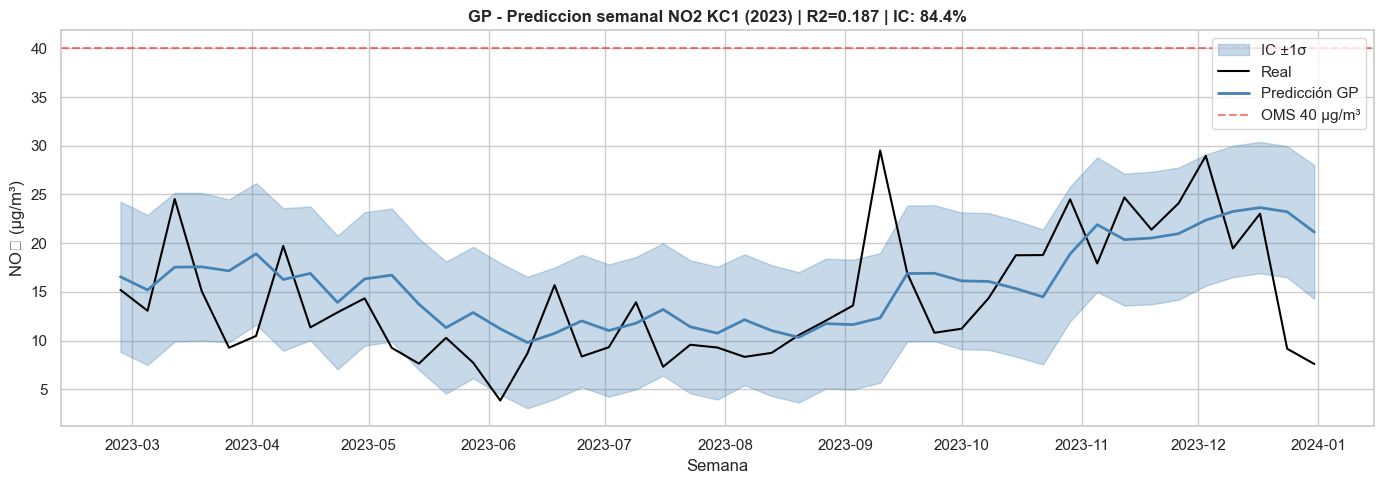

In [ ]:
# Serie semanal KC1 — evitamos el período COVID-19 (2020) para mejor generalización
no2_weekly = no2_filled['KC1'].resample('W').mean().dropna()
# Split: 2021-2022 train, 2023 test (post-COVID, régimen estable)
train_gp = no2_weekly.loc['2021':'2022']
test_gp  = no2_weekly.loc['2023']
print(f'Train GP: {len(train_gp)} semanas | Test GP: {len(test_gp)} semanas')

k = 8  # 8 semanas de contexto autoregresivo

def crear_secuencias(datos, k):
    X, y = [], []
    for i in range(k, len(datos)):
        X.append(datos[i-k:i])
        y.append(datos[i])
    return np.array(X), np.array(y)

X_tr, y_tr = crear_secuencias(train_gp.values, k)
X_te, y_te = crear_secuencias(test_gp.values, k)

scaler_gp = StandardScaler()
X_tr_sc = scaler_gp.fit_transform(X_tr)
X_te_sc = scaler_gp.transform(X_te)

y_mean_gp, y_std_gp = float(y_tr.mean()), float(y_tr.std())
y_tr_sc = (y_tr - y_mean_gp) / y_std_gp

X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float)
y_tr_t = torch.tensor(y_tr_sc, dtype=torch.float)
X_te_t = torch.tensor(X_te_sc, dtype=torch.float)

class GPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel())
    def forward(self, x):
        return MultivariateNormal(self.mean_module(x), self.covar_module(x))

likelihood = GaussianLikelihood()
gp_model   = GPModel(X_tr_t, y_tr_t, likelihood)

gp_model.train(); likelihood.train()
optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.05)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)

EPOCHS = 150
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    loss = -mll(gp_model(X_tr_t), y_tr_t)
    loss.backward()
    optimizer.step()
    if epoch % 30 == 0:
        print(f'Epoch {epoch}/{EPOCHS}  Loss: {loss.item():.5f}')

gp_model.eval(); likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(gp_model(X_te_t))
    y_pred_sc  = pred.mean.numpy()
    y_std_pred = pred.stddev.numpy()

y_pred  = y_pred_sc   * y_std_gp + y_mean_gp
y_upper = (y_pred_sc + y_std_pred) * y_std_gp + y_mean_gp
y_lower = (y_pred_sc - y_std_pred) * y_std_gp + y_mean_gp

r2_gp  = r2_score(y_te, y_pred)
ic_pct = float(np.mean((y_te >= y_lower) & (y_te <= y_upper))) * 100
print(f'R2 GP = {r2_gp:.4f}')
print(f'Puntos dentro IC +/-1sigma: {ic_pct:.1f}% (esperado ~68%)')

test_dates = test_gp.index[k:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(test_dates, y_lower, y_upper,
                alpha=0.3, color='steelblue', label='IC ±1σ')
ax.plot(test_dates, y_te,   color='black',     lw=1.5, label='Real')
ax.plot(test_dates, y_pred, color='steelblue', lw=2,   label='Predicción GP')
ax.axhline(40, color='red', ls='--', alpha=0.5, label='OMS 40 μg/m³')
ax.set_title(
    f'GP - Prediccion semanal NO2 KC1 (2023) | R2={r2_gp:.3f} | IC: {ic_pct:.1f}%',
    fontweight='bold')
ax.set_xlabel('Semana'); ax.set_ylabel('NO₂ (μg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_gp_no2.png', bbox_inches='tight')
plt.show()


## 7. Representación geográfica (RQ5) <a id='7'></a>

Se generan 6 mapas interactivos con Folium guardados en `dashboard/maps/`:

| Mapa | Contenido |
|------|-----------|
| `mapa_no2.html` | Estaciones LAQN coloreadas por NO₂ medio |
| `mapa_tfl.html` | Heatmap de paradas TfL |
| `mapa_grafo.html` | Red de conexiones GTFS |
| `mapa_conjunto.html` | LAQN + hubs TfL juntos |
| `mapa_clusters.html` | Clustering K-means de estaciones |
| `mapa_gp_pred.html` | NO₂ 2022-2023 (período test del GP) |

In [ ]:
LONDON_CENTER = [51.505, -0.105]
colormap_no2 = cm_folium.LinearColormap(
    ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97'],
    vmin=10, vmax=60, caption='NO₂ medio (μg/m³)'
)

# ── 1. NO2 por estación ──────────────────────────────────────────────────
mapa_no2 = folium.Map(location=LONDON_CENTER, zoom_start=11,
                      tiles='CartoDB positron')
for s, info in STATION_INFO.items():
    val = float(mean_no2_by_station[s])
    folium.CircleMarker(
        [info['lat'], info['lon']], radius=22,
        color='white', weight=2, fill=True,
        fill_color=colormap_no2(val), fill_opacity=0.9,
        popup=folium.Popup(
            f'<b>{s} — {info["name"]}</b><br>Tipo: {info["type"]}<br>NO₂: {val:.1f} μg/m³',
            max_width=260),
        tooltip=f'{s}: {val:.1f} μg/m³'
    ).add_to(mapa_no2)
colormap_no2.add_to(mapa_no2)
mapa_no2.save(f'{DASH_DIR}/maps/mapa_no2.html')
print('mapa_no2.html OK')
display(mapa_no2)

# ── 2. Heatmap TfL ───────────────────────────────────────────────────────
mapa_tfl = folium.Map(location=LONDON_CENTER, zoom_start=11,
                      tiles='CartoDB positron')
HeatMap(stops[['stop_lat','stop_lon']].values.tolist(),
        radius=8, blur=6).add_to(mapa_tfl)
for s, info in STATION_INFO.items():
    folium.Marker([info['lat'], info['lon']],
                  popup=f'{s} — {info["name"]}',
                  icon=folium.Icon(color='red', icon='tint', prefix='fa')
    ).add_to(mapa_tfl)
mapa_tfl.save(f'{DASH_DIR}/maps/mapa_tfl.html')
print('mapa_tfl.html OK')
display(mapa_tfl)

# ── 3. Grafo de red ───────────────────────────────────────────────────────
mapa_grafo = folium.Map(location=LONDON_CENTER, zoom_start=11,
                        tiles='CartoDB dark_matter')
hub_ids = set(gtfs_stations['stop_id'].tolist())
for u, v in list(G_main.edges)[:600]:
    if u in pos_dict and v in pos_dict:
        ln1, lt1 = pos_dict[u]
        ln2, lt2 = pos_dict[v]
        if abs(lt1-lt2) < 0.05 and abs(ln1-ln2) < 0.05:
            folium.PolyLine([[lt1,ln1],[lt2,ln2]],
                            color='#4fc3f7', weight=1.5, opacity=0.6).add_to(mapa_grafo)
for n in list(G_main.nodes)[:400]:
    if n in pos_dict:
        ln, lt = pos_dict[n]
        folium.CircleMarker(
            [lt, ln], radius=4 if n in hub_ids else 2,
            color='white', fill=True,
            fill_color='#ff7043' if n in hub_ids else '#4fc3f7',
            fill_opacity=0.8, tooltip=n[:40]
        ).add_to(mapa_grafo)
mapa_grafo.save(f'{DASH_DIR}/maps/mapa_grafo.html')
print('mapa_grafo.html OK')
display(mapa_grafo)

# ── 4. Conjunto LAQN + Hubs ───────────────────────────────────────────────
mapa_conjunto = folium.Map(location=LONDON_CENTER, zoom_start=11,
                           tiles='CartoDB positron')
mc = MarkerCluster(name='Hubs TfL').add_to(mapa_conjunto)
for _, row in gtfs_stations.iterrows():
    if pd.notna(row['stop_lat']) and pd.notna(row['stop_lon']):
        folium.Marker([row['stop_lat'], row['stop_lon']],
                      popup=str(row['stop_name'])[:50],
                      icon=folium.Icon(color='blue', icon='train', prefix='fa')
        ).add_to(mc)
for s, info in STATION_INFO.items():
    val = float(mean_no2_by_station[s])
    folium.CircleMarker(
        [info['lat'], info['lon']], radius=20,
        color='white', weight=2, fill=True,
        fill_color=colormap_no2(val), fill_opacity=0.9,
        tooltip=f'{s}: NO₂={val:.1f} μg/m³',
        popup=f'<b>{s}</b><br>{info["name"]}<br>NO₂: {val:.1f} μg/m³'
    ).add_to(mapa_conjunto)
folium.LayerControl().add_to(mapa_conjunto)
mapa_conjunto.save(f'{DASH_DIR}/maps/mapa_conjunto.html')
print('mapa_conjunto.html OK')
display(mapa_conjunto)

# ── 5. Clusters K-means ───────────────────────────────────────────────────
st_feats = pd.DataFrame({
    s: {'NO2': float(mean_no2_by_station[s]),
        'lat': info['lat'], 'lon': info['lon']}
    for s, info in STATION_INFO.items()
}).T.astype(float)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
st_feats['cluster'] = km.fit_predict(st_feats[['NO2','lat','lon']])
mapa_clusters = folium.Map(location=LONDON_CENTER, zoom_start=11,
                           tiles='CartoDB positron')
cl_colors = ['#e63946','#457b9d','#2a9d8f']
cl_names  = ['Roadside-alto NO₂','Urbano-medio','Suburbano-bajo']
for s, info in STATION_INFO.items():
    cl = int(st_feats.loc[s, 'cluster'])
    folium.CircleMarker(
        [info['lat'], info['lon']], radius=20,
        color='white', weight=2, fill=True,
        fill_color=cl_colors[cl], fill_opacity=0.9,
        tooltip=f'{s} — {cl_names[cl]}',
        popup=(f'<b>{s}</b><br>{info["name"]}<br>'
               f'Cluster: {cl_names[cl]}<br>'
               f'NO₂: {float(mean_no2_by_station[s]):.1f} μg/m³')
    ).add_to(mapa_clusters)
mapa_clusters.save(f'{DASH_DIR}/maps/mapa_clusters.html')
print('mapa_clusters.html OK')
display(mapa_clusters)

# ── 6. NO2 2022-2023 (período test GP) ───────────────────────────────────
mapa_gp = folium.Map(location=LONDON_CENTER, zoom_start=11,
                     tiles='CartoDB positron')
for s, info in STATION_INFO.items():
    recent = float(no2_filled[s].loc['2022':].mean())
    folium.CircleMarker(
        [info['lat'], info['lon']], radius=22,
        color='white', weight=2, fill=True,
        fill_color=colormap_no2(recent), fill_opacity=0.9,
        tooltip=f'{s}: NO₂ 2022-23={recent:.1f} μg/m³',
        popup=(f'<b>{s}</b><br>{info["name"]}<br>'
               f'NO₂ 2022-2023: {recent:.1f} μg/m³<br>'
               f'GP R²={r2_gp:.3f}')
    ).add_to(mapa_gp)
colormap_no2.add_to(mapa_gp)
mapa_gp.save(f'{DASH_DIR}/maps/mapa_gp_pred.html')
print('mapa_gp_pred.html OK')
display(mapa_gp)
print('\n--- Todos los mapas generados ---')

mapa_no2.html OK


mapa_tfl.html OK


mapa_grafo.html OK


mapa_conjunto.html OK


mapa_clusters.html OK


mapa_gp_pred.html OK



--- Todos los mapas generados ---


## 8. Dashboard interactivo (RQ3) <a id='8'></a>

Generamos `dashboard/index.html` con todos los KPIs, gráficas y mapas integrados en una interfaz de 6 pestañas.

In [ ]:
# Genera dashboard/index.html con todos los KPIs, graficas y mapas
exec(open('scripts/generate_dashboard.py', encoding='utf-8').read())


,Estación,Nombre / Ubicación,Tipo,NO2 medio (μg/m³),Excede OMS (40),Paradas TfL ≤500m,Dist. parada más cercana (m)
0,MY1,Westminster – Marylebone Rd,Roadside,46.81,Sí,20,111
2,WM6,Westminster – Oxford Street,Roadside,38.66,No,43,198
3,CT3,Camden – Bloomsbury,Urban Background,24.87,No,8,162
1,KC1,Kensington – North Kensington,Urban Background,20.03,No,6,448
4,BX1,Bexley – Belvedere West,Suburban,18.83,No,0,1003


Dashboard guardado: dashboard/index.html (12,339 bytes)
KPIs: NO2=29.8 | TfL=4084 | GP_R2=0.187 | IC=84.4%
      XGBoost MAE=11.294 | XGBoost R2=0.1930
